
# DS 352 • Part 2 (Exploratory) — **Notebook**
**Tools:** Python 3.x, Pandas, NumPy, Matplotlib (no seaborn)

This notebook:
1. Loads the dataset  
2. Inspects schema & missingness  
3. Summarizes nutrient columns  
4. Builds a **scatterplot matrix** of attribute pairs (nutrients)  
5. Generates accessible visuals (histograms, boxplots, correlation heatmap)  
6. Produces category summaries  
7. Performs feature engineering & discretization (for later mining)  
8. Prints simple **preliminary observations** (no deep conclusions)

> **Note:** Plots are *saved* to `eda_outputs/` (PNG) and not displayed by default to keep things snappy. You can flip a flag to show them if you prefer.


In [3]:

# ============================================================
# 0) Paths & basic setup
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Input file (already uploaded to the environment)
DATA_PATH = "usda_branded_with_nutrition_per_serving (1).csv"  # change if needed
OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Toggle to also show plots inline (default False)
SHOW_PLOTS = False

def save_current_fig(name, tight=True):
    if tight:
        plt.tight_layout()
    plt.savefig(OUT_DIR / name, dpi=150)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close()
        
print("Saving outputs to:", OUT_DIR)


Saving outputs to: eda_outputs


## 1) Load dataset

In [4]:

df = pd.read_csv(DATA_PATH, low_memory=False)
print("=== SHAPE ===")
print(df.shape)
df.head(10)


=== SHAPE ===
(1048575, 15)


,company_brand,product,branded_food_category,serving_size,serving_size_unit,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving,satfat_g_per_serving,iron_mg_per_serving,potassium_mg_per_serving
0,Richardson Oilseed Products (US) Limited,WESSON Vegetable Oil 1 GAL,Oils Edible,15.0,ml,130.05,0.0000,0.0000,13.9995,0.000,0.00,0.00,1.9995,0.0000,0.00
1,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,240.0,ml,9.60,1.9920,1.0080,0.0000,0.000,830.40,0.00,0.0000,0.0000,0.00
2,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,440.0,g,360.80,10.7800,26.9280,23.3640,1.760,1597.20,26.40,4.4880,1.0560,286.00
3,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,440.0,g,360.80,5.3680,23.3640,26.9280,1.760,1416.80,44.00,10.7800,0.7040,286.00
4,CAMPBELL SOUP COMPANY,SWANSON BROTH CHICKEN,Herbs/Spices/Extracts,240.0,ml,9.60,1.9920,1.0080,0.0000,0.000,36.00,0.00,0.0000,0.0000,28.80
5,CAMPBELL SOUP COMPANY,CAMPBELL'S SOUP BEAN AND HAM,Prepared Soups,412.0,g,251.32,15.1204,43.7132,2.5132,9.888,1260.72,16.48,0.0000,3.3784,638.60
6,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,411.0,g,16.44,3.4935,1.7673,0.0000,0.000,1450.83,0.00,0.0000,0.3699,53.43
7,CAMPBELL SOUP COMPANY,PREGO SAUCES TOMATO BASIL,Sauces/Spreads/Dips/Condiments,120.0,ml,69.60,2.0040,6.9960,3.9960,3.000,429.60,0.00,0.5040,0.3600,210.00
8,CAMPBELL SOUP COMPANY,CAMPBELL'S SOUP TOMATO,Prepared Soups,120.0,ml,90.00,2.0040,18.0000,1.5000,0.960,410.40,0.00,0.0000,0.3960,620.40
9,CAMPBELL SOUP COMPANY,CAMPBELL'S PASTA SPAGHETTIOS W FRANKS,Dough Based Products / Meals,443.0,g,385.41,15.8151,50.9893,12.3154,5.316,1054.34,44.30,3.4997,2.7909,651.21


## 2) Schema & Missingness

In [5]:

schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum().values,
    "nulls": df.isna().sum().values,
    "null_pct": (df.isna().mean().values * 100).round(2)
}).sort_values("column")

schema_path = OUT_DIR / "schema_overview.csv"
schema.to_csv(schema_path, index=False)
print("Schema saved to:", schema_path)
schema.head(20)


Schema saved to: eda_outputs\schema_overview.csv


,column,dtype,non_null,nulls,null_pct
branded_food_category,branded_food_category,object,1038120,10455,1.00
calories_per_serving,calories_per_serving,float64,1026383,22192,2.12
carbs_g_per_serving,carbs_g_per_serving,float64,1037363,11212,1.07
cholesterol_mg_per_serving,cholesterol_mg_per_serving,float64,854045,194530,18.55
company_brand,company_brand,object,1046731,1844,0.18
fat_g_per_serving,fat_g_per_serving,float64,1022425,26150,2.49
fiber_g_per_serving,fiber_g_per_serving,float64,854175,194400,18.54
iron_mg_per_serving,iron_mg_per_serving,float64,830924,217651,20.76
potassium_mg_per_serving,potassium_mg_per_serving,float64,363312,685263,65.35
product,product,object,1048574,1,0.00


## 3) Select nutrient columns & coerce numerics

In [6]:

CAND_NUTRIENTS = [
    "calories_per_serving",
    "protein_g_per_serving",
    "carbs_g_per_serving",
    "fat_g_per_serving",
    "fiber_g_per_serving",
    "sodium_mg_per_serving",
    "cholesterol_mg_per_serving",
    "satfat_g_per_serving",
    "iron_mg_per_serving",
    "potassium_mg_per_serving",
]

df_num = df.copy()
for c in df.columns:
    if df[c].dtype.kind in "biufc":
        continue
    coerced = pd.to_numeric(df[c], errors="coerce")
    if coerced.notna().mean() > 0.7 and coerced.nunique(dropna=True) > 1:
        df_num[c] = coerced

nutrients = [c for c in CAND_NUTRIENTS if c in df_num.columns]
if not nutrients:
    raise ValueError("No expected nutrient columns found. Please confirm the column names.")
nutrients


['calories_per_serving',
 'protein_g_per_serving',
 'carbs_g_per_serving',
 'fat_g_per_serving',
 'fiber_g_per_serving',
 'sodium_mg_per_serving',
 'cholesterol_mg_per_serving',
 'satfat_g_per_serving',
 'iron_mg_per_serving',
 'potassium_mg_per_serving']

## 4) Summary stats

In [7]:

stats = df_num[nutrients].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3)
stats_path = OUT_DIR / "summary_stats_nutrients.csv"
stats.to_csv(stats_path)
print("Summary stats saved to:", stats_path)
stats


Summary stats saved to: eda_outputs\summary_stats_nutrients.csv


,count,mean,std,min,5%,25%,50%,75%,95%,max
calories_per_serving,1026383.0,136.038,238.216,0.0,4.6,60.00,120.000,170.100,309.550,1.857042e+04
protein_g_per_serving,1044521.0,4.486,13.156,0.0,0.0,0.00,2.000,6.000,15.999,9.000180e+02
carbs_g_per_serving,1037363.0,18.168,40.539,0.0,0.0,4.00,15.997,25.001,43.003,7.325007e+03
fat_g_per_serving,1022425.0,5.489,9.188,0.0,0.0,0.00,3.000,8.999,17.000,9.000000e+02
fiber_g_per_serving,854175.0,1.530,3.191,0.0,0.0,0.00,1.000,2.010,5.002,3.301200e+02
sodium_mg_per_serving,1030817.0,402.362,9355.735,0.0,0.0,24.80,119.850,280.000,709.710,1.460001e+06
cholesterol_mg_per_serving,854045.0,33.310,1104.374,0.0,0.0,0.00,0.000,15.300,60.060,2.349991e+05
satfat_g_per_serving,883063.0,2.279,4.176,0.0,0.0,0.00,1.001,3.500,8.000,9.000000e+02
iron_mg_per_serving,830924.0,2.344,353.133,0.0,0.0,0.00,0.701,1.085,2.706,3.000000e+05
potassium_mg_per_serving,363312.0,6186.698,3484018.868,0.0,0.0,43.95,122.400,239.970,480.000,2.100000e+09


## 5) Missingness bar (saved as PNG)

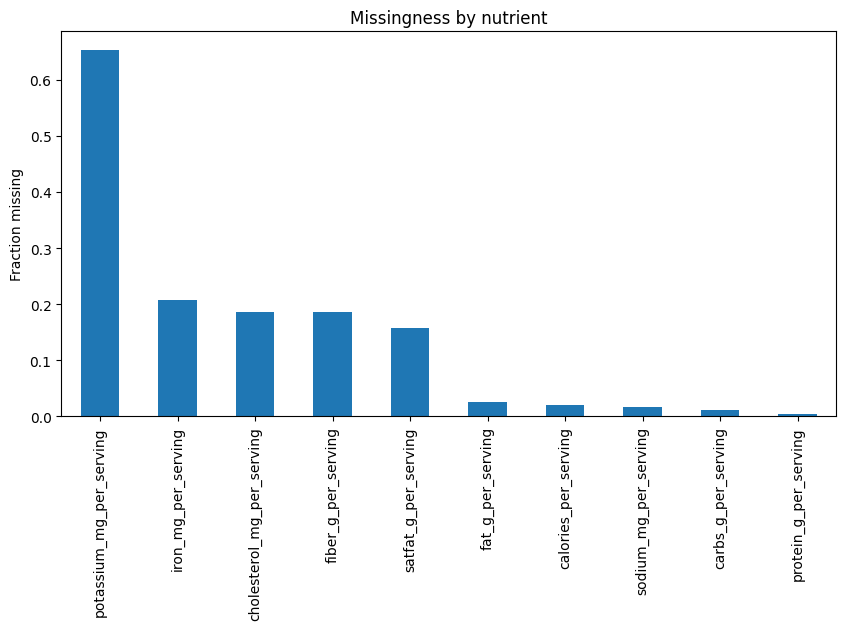

potassium_mg_per_serving      0.653518
iron_mg_per_serving           0.207568
cholesterol_mg_per_serving    0.185518
fiber_g_per_serving           0.185394
satfat_g_per_serving          0.157845
fat_g_per_serving             0.024939
calories_per_serving          0.021164
sodium_mg_per_serving         0.016935
carbs_g_per_serving           0.010693
protein_g_per_serving         0.003866
dtype: float64

In [9]:

miss = df_num[nutrients].isna().mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
miss.plot(kind="bar")
plt.title("Missingness by nutrient")
plt.ylabel("Fraction missing")
plt.show()
save_current_fig("missingness_nutrients.png")
miss.head(10)


## 6) Correlation heatmap (saved as PNG)

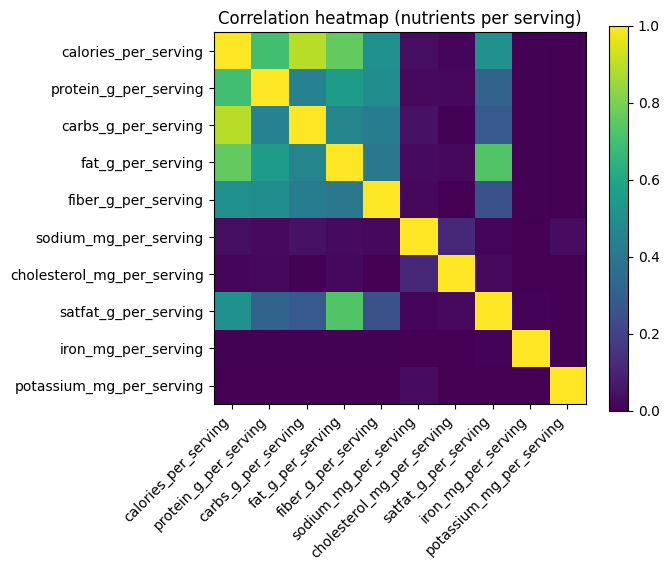

calories_per_serving   carbs_g_per_serving      0.891573
carbs_g_per_serving    calories_per_serving     0.891573
calories_per_serving   fat_g_per_serving        0.760112
fat_g_per_serving      calories_per_serving     0.760112
                       satfat_g_per_serving     0.727587
satfat_g_per_serving   fat_g_per_serving        0.727587
protein_g_per_serving  calories_per_serving     0.697891
calories_per_serving   protein_g_per_serving    0.697891
fat_g_per_serving      protein_g_per_serving    0.548199
protein_g_per_serving  fat_g_per_serving        0.548199
Name: corr, dtype: float64

In [10]:

corr = df_num[nutrients].corr()
plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(nutrients)), nutrients, rotation=45, ha='right')
plt.yticks(range(len(nutrients)), nutrients)
plt.title("Correlation heatmap (nutrients per serving)")
plt.colorbar()
plt.show()
save_current_fig("corr_heatmap_nutrients.png")

# show the strongest absolute correlations (pairs)
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .rename("corr")
        .abs()
        .sort_values(ascending=False)
)
corr_pairs.head(10)


## 7) Scatterplot **matrix** of nutrient attributes

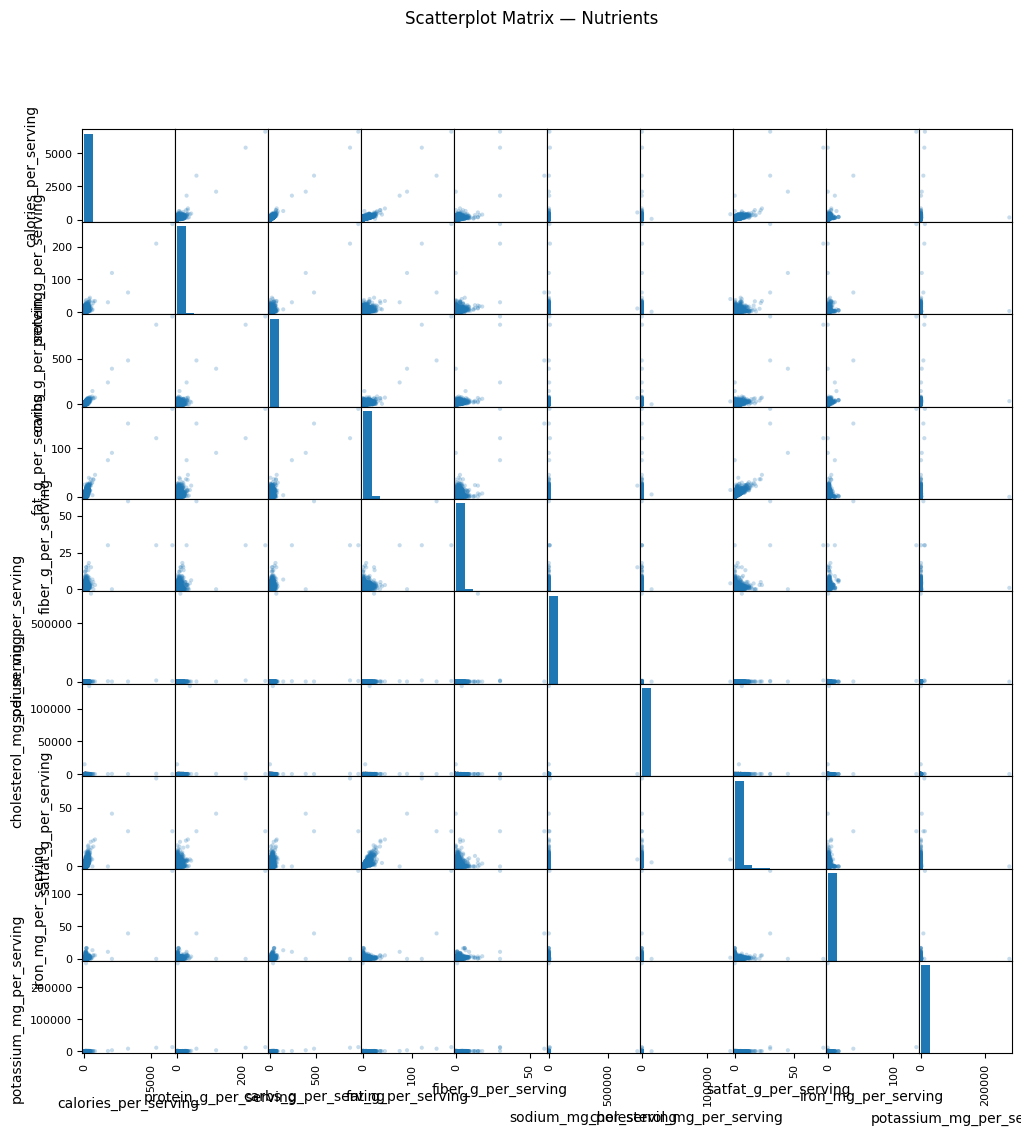

,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving,satfat_g_per_serving,iron_mg_per_serving,potassium_mg_per_serving
174348,120.00,1.0000,32.000,0.0000,2.000,0.00,0.00,0.0000,0.7200,300.00
421108,199.75,15.0025,30.005,2.5075,5.950,650.25,46.75,1.0200,1.7850,471.75
557543,150.00,2.0010,18.000,8.0010,2.010,9.90,0.00,3.9990,0.9990,129.90
1018989,280.33,2.9973,29.003,18.0032,0.970,85.36,34.92,9.0016,0.9991,164.90
24527,339.90,3.9996,33.000,21.0012,5.016,349.80,0.00,11.0022,0.8976,120.12


In [11]:

# To avoid heavy overplotting, sample if many rows
SAMPLE_FOR_MATRIX = 1500  # set to None to use full data
df_for_matrix = df_num[nutrients].dropna()
if SAMPLE_FOR_MATRIX and len(df_for_matrix) > SAMPLE_FOR_MATRIX:
    df_for_matrix = df_for_matrix.sample(SAMPLE_FOR_MATRIX, random_state=42)

axarr = scatter_matrix(df_for_matrix, figsize=(12, 12), diagonal='hist', alpha=0.25)
plt.suptitle("Scatterplot Matrix — Nutrients")
plt.show()
save_current_fig("scatter_matrix_nutrients.png")

df_for_matrix.head()


## 8) Histograms & Boxplots (saved as PNGs)

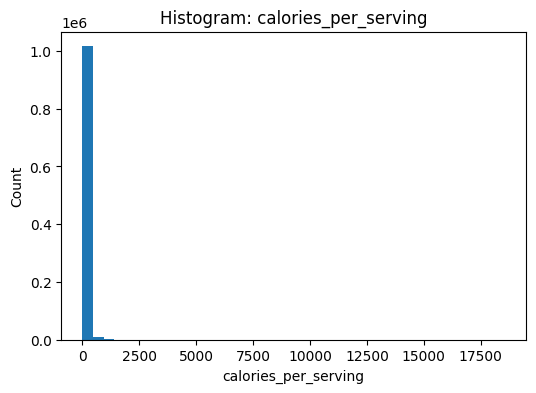

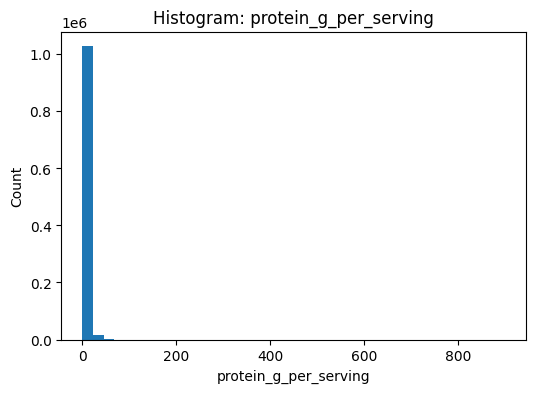

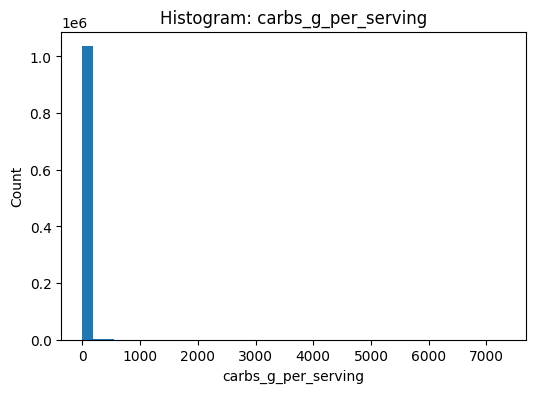

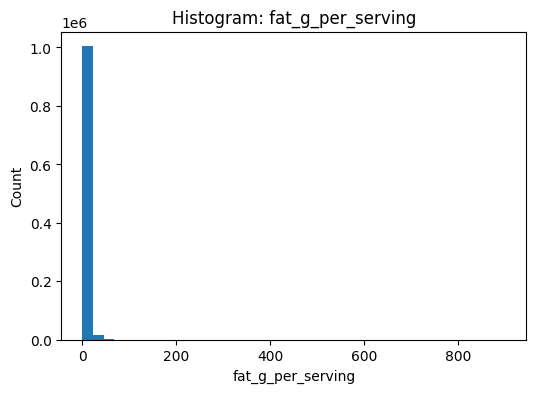

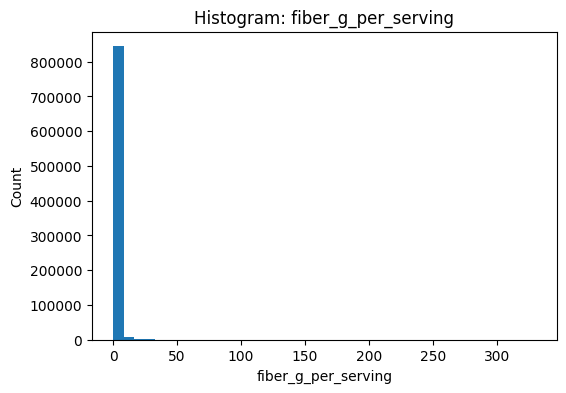

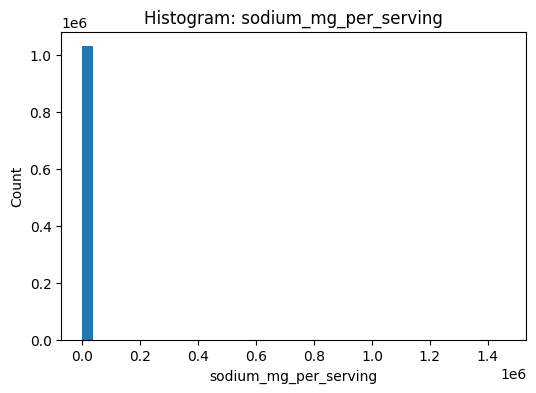

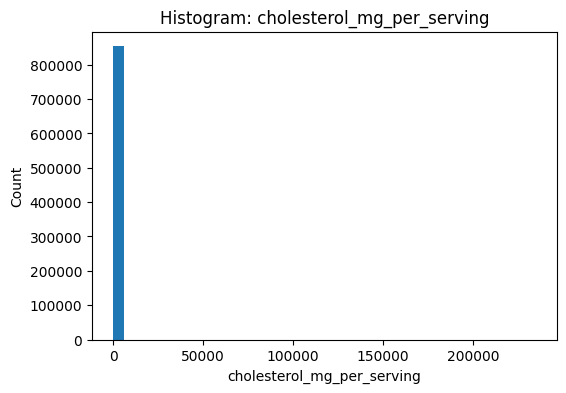

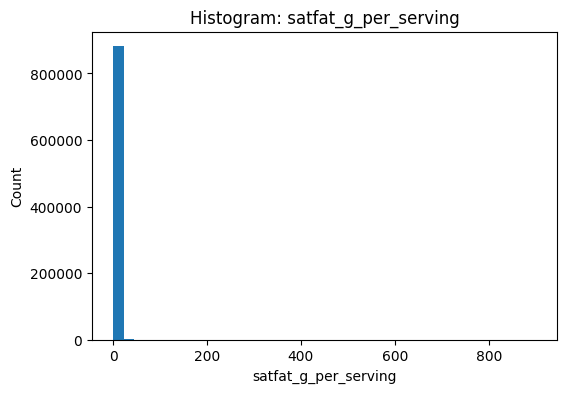

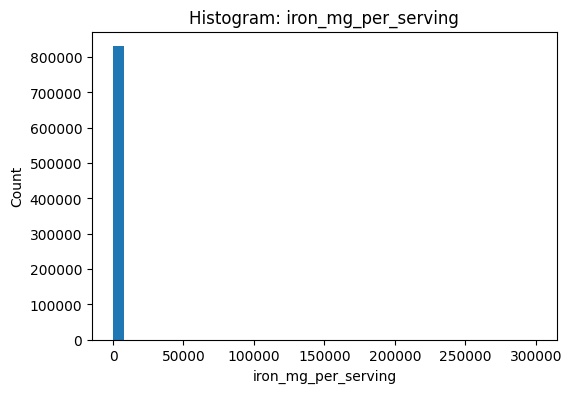

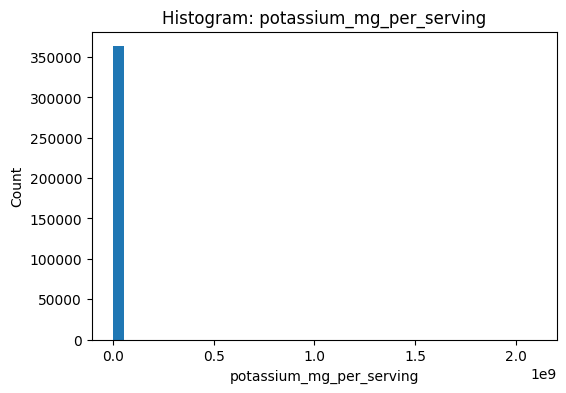

'Saved to eda_outputs/'

In [12]:

for col in nutrients:
    # Histogram
    plt.figure(figsize=(6, 4))
    df_num[col].dropna().plot(kind="hist", bins=40)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    save_current_fig(f"hist_{col}.png")

    # Boxplot
    plt.figure(figsize=(4, 4))
    plt.boxplot(df_num[col].dropna().values, vert=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    save_current_fig(f"box_{col}.png")

"Saved to eda_outputs/"


## 9) Category summaries (if a category column is present)

In [13]:

cat_col = None
for cand in ["branded_food_category", "category_family", "category", "food_category"]:
    if cand in df.columns:
        cat_col = cand
        break

if cat_col:
    agg_cols = {}
    if "calories_per_serving" in df_num.columns:
        agg_cols["kcal_med"] = ("calories_per_serving", "median")
    if "sodium_mg_per_serving" in df_num.columns:
        agg_cols["sodium_med"] = ("sodium_mg_per_serving", "median")
    if "fiber_g_per_serving" in df_num.columns:
        agg_cols["fiber_med"] = ("fiber_g_per_serving", "median")

    if not agg_cols:
        agg_cols["n"] = ("calories_per_serving", "count")

    cat_summary = df_num.groupby(cat_col).agg(
        n=("calories_per_serving", "count") if "calories_per_serving" in df_num.columns else ("protein_g_per_serving","count"),
        **agg_cols
    ).sort_values("n", ascending=False)

    cat_summary_path = OUT_DIR / "category_summary.csv"
    cat_summary.to_csv(cat_summary_path)
    print("Category summary saved to:", cat_summary_path)
    display(cat_summary.head(15))
else:
    print("No category column found among: branded_food_category, category_family, category, food_category")


Category summary saved to: eda_outputs\category_summary.csv


,n,kcal_med,sodium_med,fiber_med
branded_food_category,,,,
"Popcorn, Peanuts, Seeds & Related Snacks",50901,162.960,80.100000,2.001
Candy,50043,120.000,15.120000,0.000
Cheese,42238,90.000,180.040000,0.000
Ice Cream & Frozen Yogurt,33191,160.190,59.840000,0.000
Cookies & Biscuits,29513,140.100,90.060000,0.990
"Chips, Pretzels & Snacks",27519,140.049,180.000000,1.008
"Pickles, Olives, Peppers & Relishes",25266,19.950,229.960000,0.990
Breads & Buns,24848,119.970,209.760000,1.014
"Fruit & Vegetable Juice, Nectars & Fruit Drinks",22708,110.400,19.200000,0.000


## 10) Feature engineering (for later mining)

In [14]:

df_eng = df_num.copy()

# Sodium per kcal
if {"sodium_mg_per_serving","calories_per_serving"}.issubset(df_eng.columns):
    df_eng["sodium_mg_per_kcal"] = df_eng["sodium_mg_per_serving"] / df_eng["calories_per_serving"].clip(lower=1)

# Saturated fat share
if {"satfat_g_per_serving","fat_g_per_serving"}.issubset(df_eng.columns):
    df_eng["satfat_share"] = (df_eng["satfat_g_per_serving"] / df_eng["fat_g_per_serving"].replace(0, np.nan)).clip(0,1)

# Macro pct of kcal
if "calories_per_serving" in df_eng.columns:
    kcal = df_eng["calories_per_serving"].clip(lower=1)
    if "protein_g_per_serving" in df_eng.columns:
        df_eng["protein_pct"] = (4*df_eng["protein_g_per_serving"] / kcal).clip(0,1)
    if "carbs_g_per_serving" in df_eng.columns:
        df_eng["carb_pct"] = (4*df_eng["carbs_g_per_serving"] / kcal).clip(0,1)
    if "fat_g_per_serving" in df_eng.columns:
        df_eng["fat_pct"] = (9*df_eng["fat_g_per_serving"] / kcal).clip(0,1)

# Sodium bands (FDA-ish DV guidance)
if "sodium_mg_per_serving" in df_eng.columns:
    df_eng["sodium_band"] = pd.cut(
        df_eng["sodium_mg_per_serving"],
        bins=[-0.1, 140, 460, df_eng["sodium_mg_per_serving"].max() + 1],
        labels=["low","moderate","high"]
    )
    df_eng["is_high_sodium"] = (df_eng["sodium_mg_per_serving"] >= 460).astype(int)

enhanced_path = OUT_DIR / "usda_branded_enhanced.csv"
df_eng.to_csv(enhanced_path, index=False)
print("Enhanced dataset saved to:", enhanced_path)
df_eng.head(5)


Enhanced dataset saved to: eda_outputs\usda_branded_enhanced.csv


,company_brand,product,branded_food_category,serving_size,serving_size_unit,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,...,satfat_g_per_serving,iron_mg_per_serving,potassium_mg_per_serving,sodium_mg_per_kcal,satfat_share,protein_pct,carb_pct,fat_pct,sodium_band,is_high_sodium
0,Richardson Oilseed Products (US) Limited,WESSON Vegetable Oil 1 GAL,Oils Edible,15.0,ml,130.05,0.000,0.000,13.9995,0.00,...,1.9995,0.000,0.0,0.000000,0.142827,0.000000,0.000000,0.968824,low,0
1,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,240.0,ml,9.60,1.992,1.008,0.0000,0.00,...,0.0000,0.000,0.0,86.500000,NaN,0.830000,0.420000,0.000000,high,1
2,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,440.0,g,360.80,10.780,26.928,23.3640,1.76,...,4.4880,1.056,286.0,4.426829,0.192090,0.119512,0.298537,0.582805,high,1
3,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,440.0,g,360.80,5.368,23.364,26.9280,1.76,...,10.7800,0.704,286.0,3.926829,0.400327,0.059512,0.259024,0.671707,high,1
4,CAMPBELL SOUP COMPANY,SWANSON BROTH CHICKEN,Herbs/Spices/Extracts,240.0,ml,9.60,1.992,1.008,0.0000,0.00,...,0.0000,0.000,28.8,3.750000,NaN,0.830000,0.420000,0.000000,low,0


## 11) Discretization (quartiles) + optional one-hot (for later mining)

In [15]:

disc_cols = [c for c in nutrients if c in df_eng.columns]
for c in disc_cols:
    try:
        df_eng[c + "_q4"] = pd.qcut(df_eng[c], q=4, labels=["very_low","low","high","very_high"])
    except ValueError:
        pass  # too few unique values

one_hot_cols = []
if "sodium_band" in df_eng.columns:
    one_hot_cols.append("sodium_band")
for c in disc_cols:
    qcol = c + "_q4"
    if qcol in df_eng.columns:
        one_hot_cols.append(qcol)

if one_hot_cols:
    dummies = pd.get_dummies(df_eng[one_hot_cols], drop_first=False, dtype=int)
    df_bin = pd.concat([df_eng, dummies], axis=1)
else:
    df_bin = df_eng.copy()

bin_path = OUT_DIR / "usda_branded_enhanced_with_dummies.csv"
df_bin.to_csv(bin_path, index=False)
print("Enhanced + dummies dataset saved to:", bin_path)
df_bin.head(5)


Enhanced + dummies dataset saved to: eda_outputs\usda_branded_enhanced_with_dummies.csv


,company_brand,product,branded_food_category,serving_size,serving_size_unit,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,...,carbs_g_per_serving_q4_high,carbs_g_per_serving_q4_very_high,sodium_mg_per_serving_q4_very_low,sodium_mg_per_serving_q4_low,sodium_mg_per_serving_q4_high,sodium_mg_per_serving_q4_very_high,potassium_mg_per_serving_q4_very_low,potassium_mg_per_serving_q4_low,potassium_mg_per_serving_q4_high,potassium_mg_per_serving_q4_very_high
0,Richardson Oilseed Products (US) Limited,WESSON Vegetable Oil 1 GAL,Oils Edible,15.0,ml,130.05,0.000,0.000,13.9995,0.00,...,0,0,1,0,0,0,1,0,0,0
1,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,240.0,ml,9.60,1.992,1.008,0.0000,0.00,...,0,0,0,0,0,1,1,0,0,0
2,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,440.0,g,360.80,10.780,26.928,23.3640,1.76,...,0,1,0,0,0,1,0,0,0,1
3,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,440.0,g,360.80,5.368,23.364,26.9280,1.76,...,1,0,0,0,0,1,0,0,0,1
4,CAMPBELL SOUP COMPANY,SWANSON BROTH CHICKEN,Herbs/Spices/Extracts,240.0,ml,9.60,1.992,1.008,0.0000,0.00,...,0,0,0,1,0,0,1,0,0,0


## 12) Programmatic preliminary observations (printed)

In [16]:

print("=== PRELIMINARY OBSERVATIONS (auto-generated) ===")

# a) Highest missingness
top_missing = (df_num[nutrients].isna().mean().sort_values(ascending=False) * 100).round(2)
print("\n- Highest missingness (% of rows):")
print(top_missing.head(5))

# b) Top absolute correlations
from numpy import triu_indices
print("\n- Strongest absolute correlations among nutrients (|r|):")
print(corr_pairs.head(10))

# c) Category-level high-sodium rate (if possible)
cat_col = None
for cand in ["branded_food_category", "category_family", "category", "food_category"]:
    if cand in df.columns:
        cat_col = cand
        break

if cat_col and "is_high_sodium" in df_eng.columns:
    rate = df_eng.groupby(cat_col)["is_high_sodium"].mean().sort_values(ascending=False)
    print("\n- Categories with highest share of high-sodium items:")
    print((rate.head(10) * 100).round(1).astype(str) + "%")

# d) Macro energy share sanity check (median by category if available)
if cat_col and {"protein_pct","carb_pct","fat_pct"}.issubset(df_eng.columns):
    macro_med = df_eng.groupby(cat_col)[["protein_pct","carb_pct","fat_pct"]].median().sort_values("carb_pct", ascending=False)
    print("\n- Median macro energy share by category (top by carb_pct):")
    print((macro_med.head(10) * 100).round(1).astype(str) + "%")

print("\n[Done] Figures saved to:", OUT_DIR)


=== PRELIMINARY OBSERVATIONS (auto-generated) ===

- Highest missingness (% of rows):
potassium_mg_per_serving      65.35
iron_mg_per_serving           20.76
cholesterol_mg_per_serving    18.55
fiber_g_per_serving           18.54
satfat_g_per_serving          15.78
dtype: float64

- Strongest absolute correlations among nutrients (|r|):
calories_per_serving   carbs_g_per_serving      0.891573
carbs_g_per_serving    calories_per_serving     0.891573
calories_per_serving   fat_g_per_serving        0.760112
fat_g_per_serving      calories_per_serving     0.760112
                       satfat_g_per_serving     0.727587
satfat_g_per_serving   fat_g_per_serving        0.727587
protein_g_per_serving  calories_per_serving     0.697891
calories_per_serving   protein_g_per_serving    0.697891
fat_g_per_serving      protein_g_per_serving    0.548199
protein_g_per_serving  fat_g_per_serving        0.548199
Name: corr, dtype: float64

- Categories with highest share of high-sodium items:
branded_f